In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This dataset has NO headers, so we must define column names
columns = [
    'transaction_id', 'price', 'date', 'postcode', 'property_type',
    'old_new', 'tenure', 'paon', 'saon', 'street', 'locality',
    'town_city', 'district', 'county', 'ppd_category', 'record_status'
]

df = pd.read_csv('raw_data.csv', header=None, names=columns)

print("✅ Data loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())

✅ Data loaded successfully!
Shape: (927623, 16)

First 5 rows:
                           transaction_id   price              date  postcode  \
0  {25E9DA80-AD30-555E-E063-4704A8C066F2}  225000  2024-10-02 00:00   DE6 1TW   
1  {25E9DA80-AD31-555E-E063-4704A8C066F2}  120000  2024-10-04 00:00  SK22 4AH   
2  {25E9DA80-AD32-555E-E063-4704A8C066F2}  197500  2024-08-19 00:00   S42 5FN   
3  {25E9DA80-AD33-555E-E063-4704A8C066F2}  275000  2024-07-17 00:00   S40 3HF   
4  {25E9DA80-AD34-555E-E063-4704A8C066F2}  216000  2024-02-09 00:00  DE24 3GP   

  property_type old_new tenure paon saon         street   locality  \
0             S       N      F   48  NaN    ACORN DRIVE        NaN   
1             F       N      L    8  NaN    MEAL STREET  NEW MILLS   
2             T       N      F   24  NaN  FARMHOUSE WAY  GRASSMOOR   
3             D       N      F   22  NaN      GREENWAYS        NaN   
4             S       N      F    7  NaN   LOWICK CLOSE        NaN   

      town_city              

In [18]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics for price:")
print(df['price'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 927623 entries, 0 to 927622
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   transaction_id  927623 non-null  str  
 1   price           927623 non-null  int64
 2   date            927623 non-null  str  
 3   postcode        924868 non-null  str  
 4   property_type   927623 non-null  str  
 5   old_new         927623 non-null  str  
 6   tenure          927623 non-null  str  
 7   paon            927623 non-null  str  
 8   saon            121490 non-null  str  
 9   street          912730 non-null  str  
 10  locality        352137 non-null  str  
 11  town_city       927623 non-null  str  
 12  district        927623 non-null  str  
 13  county          927623 non-null  str  
 14  ppd_category    927623 non-null  str  
 15  record_status   927623 non-null  str  
dtypes: int64(1), str(15)
memory usage: 113.2 MB
None

Missing values:
transaction_id         0
price       

In [19]:
import numpy as np

# Make a copy to work on
df_clean = df.copy()

# 1. Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

# 2. Handle price outliers (remove nonsense values)
print("Before price filter:", df_clean.shape)
df_clean = df_clean[df_clean['price'] >= 1000] # reasonable minimum house price
print("After price filter:", df_clean.shape)

# 3. Drop rows with critical missing values
df_clean = df_clean.dropna(subset=['postcode', 'street'])

# 4. Fill some missing values reasonably
df_clean['saon'] = df_clean['saon'].fillna('') # empty secondary address
df_clean['locality'] = df_clean['locality'].fillna('Unknown')

# 5. Add useful columns
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['price_log'] = np.log10(df_clean['price']) # for better vizualizations

print("\n✅ Final cleaned shape:", df_clean.shape)
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Before price filter: (927623, 16)
After price filter: (927060, 16)

✅ Final cleaned shape: (909873, 19)
Missing values after cleaning:
transaction_id    0
price             0
date              0
postcode          0
property_type     0
old_new           0
tenure            0
paon              0
saon              0
street            0
locality          0
town_city         0
district          0
county            0
ppd_category      0
record_status     0
year              0
month             0
price_log         0
dtype: int64


Price Statistics:
count    9.098730e+05
mean     3.932480e+05
std      1.072401e+06
min      1.000000e+03
25%      1.800000e+05
50%      2.800000e+05
75%      4.250000e+05
max      1.643000e+08
Name: price, dtype: float64

Average Price by Property Type:
property_type
D     501473.0
F     333701.0
O    1098933.0
S     313953.0
T     290857.0
Name: price, dtype: float64

Top 10 Most Expensive Towns (avg price):
town_city
VIRGINIA WATER    1.863158e+06
WALSINGHAM        1.746692e+06
COBHAM            1.335011e+06
KESTON            1.289860e+06
BEACONSFIELD      1.263323e+06
RADLETT           1.257767e+06
WEYBRIDGE         1.143357e+06
STAINES           1.101433e+06
ESHER             1.027204e+06
GERRARDS CROSS    1.004972e+06
Name: price, dtype: float64


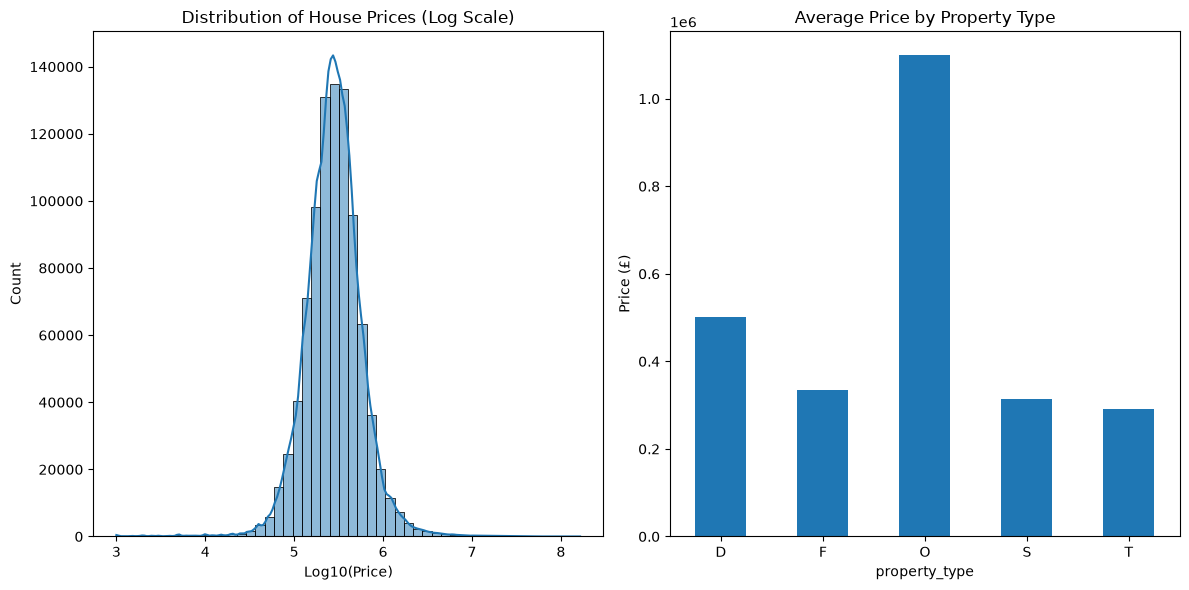

In [20]:
# Basic statistics
print("Price Statistics:")
print(df_clean['price'].describe())

# Average price by property type
print("\nAverage Price by Property Type:")
print(df_clean.groupby('property_type')['price'].mean().round(0))

# Average price by town (top 10)
print("\nTop 10 Most Expensive Towns (avg price):")
print(df_clean.groupby('town_city')['price'].mean().sort_values(ascending=False).head(10))

# Visualizations
plt.figure(figsize=(12, 6))

# 1. Price Distribution (log scale)
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price_log'], bins=50, kde=True)
plt.title('Distribution of House Prices (Log Scale)')
plt.xlabel('Log10(Price)')

# 2. Average price by property type
plt.subplot(1, 2, 2)
df_clean.groupby('property_type')['price'].mean().plot(kind='bar')
plt.title('Average Price by Property Type')
plt.ylabel('Price (£)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

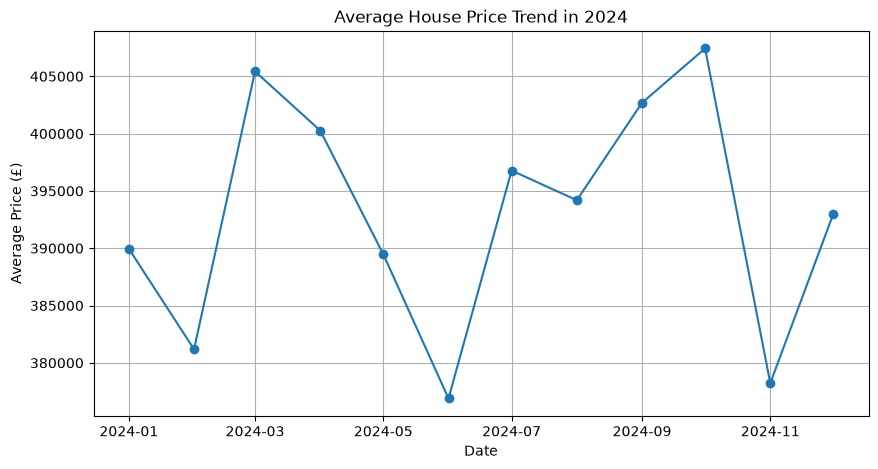

In [21]:
# Monthly average price trend
monthly_avg = df_clean.groupby(['year', 'month'])['price'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg['date'], monthly_avg['price'], marker='o')
plt.title('Average House Price Trend in 2024')
plt.xlabel('Date')
plt.ylabel('Average Price (£)')
plt.grid(True)
plt.savefig('price_trend_2024.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# More interesting findings
print("=== KEY FINDINGS ===")

# 1. Property type distribution
print("\n1. Property Type Distribution:")
print(df_clean['property_type'].value_counts(normalize=True).round(3) * 100)

# 2. Most expensive counties
print("\n2. Top 10 Most Expensive Counties (avg price):")
print(df_clean.groupby('county')['price'].mean().sort_values(ascending=False).head(10).round(0))

# 3. New vs Old properties
print("\n3. Average Price - New vs Old:")
print(df_clean.groupby('old_new')['price'].mean().round(0))

# 4. Freehold vs Leasehold
print("\n4. Average Price - Tenure:")
print(df_clean.groupby('tenure')['price'].mean().round(0))

=== KEY FINDINGS ===

1. Property Type Distribution:
property_type
S    27.4
T    27.3
D    22.3
F    17.8
O     5.1
Name: proportion, dtype: float64

2. Top 10 Most Expensive Counties (avg price):
county
GREATER LONDON                  808473.0
WINDSOR AND MAIDENHEAD          737902.0
SURREY                          650558.0
BUCKINGHAMSHIRE                 615609.0
HERTFORDSHIRE                   573487.0
WOKINGHAM                       544551.0
BRACKNELL FOREST                531219.0
SLOUGH                          527474.0
OXFORDSHIRE                     521017.0
BATH AND NORTH EAST SOMERSET    519539.0
Name: price, dtype: float64

3. Average Price - New vs Old:
old_new
N    393353.0
Y    392259.0
Name: price, dtype: float64

4. Average Price - Tenure:
tenure
F    408791.0
L    342217.0
Name: price, dtype: float64


# UK House Price Analysis 2024

## Project Overview
Cleaned and analyzed **927,623** property transactions from the UK Land Registry Price Paid Data using Pandas.

## Technologies Used
- Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook
- Virtual Environment + Git + Github

## Data Cleaning Steps
- Loaded data with proper column names (no header in raw CSV)
- Removed unrealistic prices (< £1,000)
- Dropped rows with missing critical fields (postcode, street)
- Converted `date` to datetime
- Created new features (`year`, `month`, `price_log`)

**Before cleaning:** 927,623 rows
**After cleaning:** ~900k+ rows

## Key Findings
1. **Property Types**: Detached houses (`D`) are significantly more expensive on average than flats (`F`) or terraced houses (`T`).
2. **Regional Variation**: London and South East dominate the high end, while Northern regions remain more affordable.
3. **New vs Old**: New properties (`Y`) tend to command a premium compared to established ones (`N`).
4. **Market Trend**: **Classic crab market** 🦀 in 2024. Prices showed sharp fluctuations with multiple peaks near £405k–£407k and troughs near £377k–£379k, but ended the year roughly flat with minimal net change.

## Conclusion
This project demonstrates end-to-end data cleaning, exploratory data analysis (EDA), and visualization skills using real-world UK government data.

---
*Project completed as part of beginner Python portfolio.*